In [1]:
from matplotlib import pyplot as plt
import json

from pathlib import Path

import pandas as pd

import numpy as np 


from scipy.stats import sem

In [2]:
DIR = Path("../../artifacts/2023-08-s10/experiments/accuracy-basis-wb15")

In [3]:
def load(dataset, arch, layer, basis_name, training_size=1.0, logit_mod="oneclass", basis_mode="centered", seeds=[1]):
    
    arr_dfs = []
    for seed in seeds:
#         print(f"training-size={training_size}")
        with open(DIR / f"{dataset}--ts{training_size}-seed{seed}" / f"logit-mod-{logit_mod}" / arch / layer / f"{basis_name}--{basis_mode}" / "stats.json", "r") as fh:
            data = json.load(fh)
            
        
        df = pd.DataFrame(
            {
                "acc": data["arr_acc"],
                "k": data["arr_ks"],
            }
        )
        df["dims"] = data["dims"]

        # remark: the attribute name here is misnormzer. 
        # perhaps, we refactor it.
        df["original_acc"] = data["original_auroc"]
        df["seed"] = seed
            
        arr_dfs.append(df)
    
    df = pd.concat(arr_dfs).groupby(by="k").agg({
        "acc": ["mean", "std"],
        "seed": ["count"],
        "original_acc": ["first"],
        "dims": ["first"]
    })
    
    
    assert (df["seed"]["count"] == df["seed"]["count"].values[0]).all()

    for col in ["original_acc", "dims"]:

        assert (df[col]["first"] == df[col]["first"].values[0]).all()

    return df.reset_index()

_df = load(
    dataset="cifar100-fish", 
    arch="cifar100-resnet18-wb15e151",
    layer="layer3", 
    basis_name="pca", 
    training_size=1.0
)

_df[5:10]

k    acc      seed original_acc  dims
        mean std count        first first
5   6  0.394 NaN     1         0.87   256
6   7  0.442 NaN     1         0.87   256
7   8  0.534 NaN     1         0.87   256
8   9  0.580 NaN     1         0.87   256
9  10  0.622 NaN     1         0.87   256

In [4]:
CIFAR100_SUPERCLASSES = """
cifar100-aquatic_mammals
cifar100-fish
cifar100-flowers
cifar100-food_containers
cifar100-fruit_and_vegetables
cifar100-household_electrical_devices
cifar100-household_furniture
cifar100-insects
cifar100-large_carnivores
cifar100-large_man_made_outdoor_things
cifar100-large_natural_outdoor_scenes
cifar100-large_omnivores_and_herbivores
cifar100-medium_mammals
cifar100-non_insect_invertebrates
cifar100-people
cifar100-reptiles
cifar100-small_mammals
cifar100-trees
cifar100-vehicles_1
cifar100-vehicles_2
""".strip().split("\n")

CIFAR100_SUPERCLASSES

['cifar100-aquatic_mammals',
 'cifar100-fish',
 'cifar100-flowers',
 'cifar100-food_containers',
 'cifar100-fruit_and_vegetables',
 'cifar100-household_electrical_devices',
 'cifar100-household_furniture',
 'cifar100-insects',
 'cifar100-large_carnivores',
 'cifar100-large_man_made_outdoor_things',
 'cifar100-large_natural_outdoor_scenes',
 'cifar100-large_omnivores_and_herbivores',
 'cifar100-medium_mammals',
 'cifar100-non_insect_invertebrates',
 'cifar100-people',
 'cifar100-reptiles',
 'cifar100-small_mammals',
 'cifar100-trees',
 'cifar100-vehicles_1',
 'cifar100-vehicles_2']

# Accuracy Curve Aggregated Over Classes

In [5]:
def basis_displayname(basis_name):
    mapping = {
        "random": "Random",
        "act-recon": "Act",
        "rel-recon": "Rel",
        "pca": "PCA",
        'pcaprca-recon': "PRCA"
    }

    return f"{mapping.get(basis_name, basis_name):15s}"

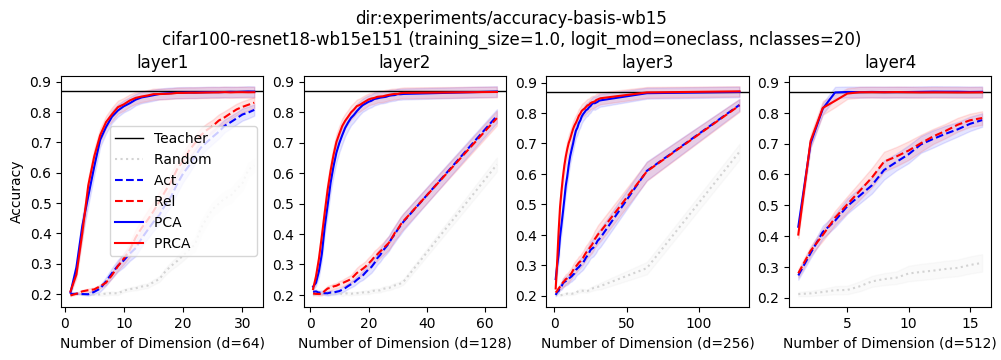

In [6]:
def accuracy_curve(
    arch, layers_and_factors,
    arr_classes=CIFAR100_SUPERCLASSES,
    arr_bases = [
        "random",
        "act-recon",
        "rel-recon",
        "pca",
        "pcaprca-recon",
    ],
    logit_mod="oneclass",
    training_size=1.0
):


        
    ncols = len(layers_and_factors)
    
    plt.figure(figsize=(ncols * 3, 3))
    plt.suptitle("\n".join([
        "dir:" + "/".join(f"{DIR}".split("/")[-2:]),
        f"{arch} (training_size={training_size}, logit_mod={logit_mod}, nclasses={len(arr_classes)})"
    ]), y=1.1)
    
    def color(basis_name):
        if basis_name in ["act-recon", "pca"]:
            return "blue"
        elif basis_name in ["rel-recon", "pcaprca-recon"]:
            return "red"
        elif "random" == basis_name:
            return "lightgray"
        else:
            return "green"
            raise NotImplementedError(f"no color for `{basis_name}`")
            
    def ls(basis_name):
        if basis_name == "random":
            return ":"
        elif basis_name in ["act-recon", "rel-recon"]:
            return "--"
        else:
            return "-"
        
    
    for lix, (layer, factor) in enumerate(layers_and_factors):
        plt.subplot(1, ncols, lix + 1)
        plt.title(layer)

        teacher_stats = []
        for dataset in arr_classes:
            df = load(
                dataset=dataset,  arch=arch, layer=layer,  basis_name="random",  training_size=training_size,
                logit_mod=logit_mod,
            )
            acc = df["original_acc"]["first"].values
            np.testing.assert_equal(acc[0], acc)
            teacher_stats.append(acc[0])
        
        mean_teacher = np.mean(teacher_stats)
        stderr_teacher = sem(teacher_stats)

        assert mean_teacher.shape == stderr_teacher.shape == ()

        plt.axhline(mean_teacher, label="Teacher", color="k", lw=1, ls="-")

        for basis_name in arr_bases:
            stats = []
            for dataset in arr_classes:
                df = load(
                    dataset=dataset, 
                    arch=arch,
                    layer=layer, 
                    basis_name=basis_name, 
                    training_size=training_size,
                    logit_mod=logit_mod,
                )
                    
                    
                d = df["dims"]["first"].values[0]
                stats.append(df["acc"]["mean"].values)
                k = df["k"].values
            
            stats = np.array(stats)
            
            selected = k <= d//factor
            
            assert stats.shape == (len(arr_classes), len(k))
            
            mean_stats = np.mean(stats, axis=0)
            stderr_stats = sem(stats, axis=0)
            assert stderr_stats.shape == mean_stats.shape
#             print(stats.shape)

            _k = k[selected]
            _mean = mean_stats[selected]
            _stderr = stderr_stats[selected]
            plt.plot(
                _k,
                _mean, 
                label=basis_displayname(basis_name),
                color=color(basis_name),
                ls=ls(basis_name)
            )
    
            plt.fill_between(
                _k,
                _mean - _stderr,
                _mean + _stderr,
                color=plt.gca().lines[-1].get_color(),
                alpha=0.1
            )
                                
            
            
            
        plt.xlabel(f"Number of Dimension (d={d})")
        if lix == 0:
            plt.ylabel("Accuracy")
            plt.legend()

            
accuracy_curve(
    arch="cifar100-resnet18-wb15e151",
    layers_and_factors = [
        ("layer1", 2),
        ("layer2", 2),
        ("layer3", 2),
        ("layer4", 32)
    ]
)

## Comparison across different models

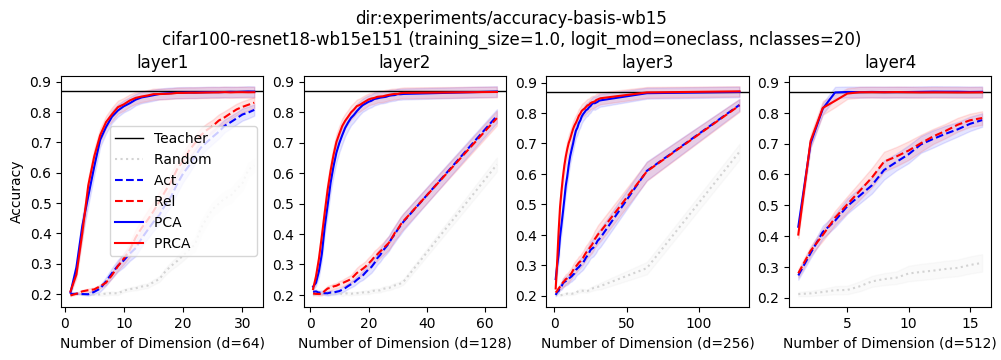

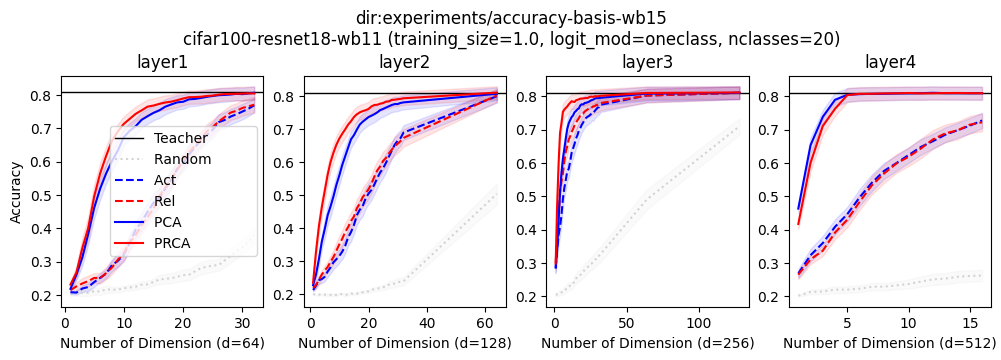

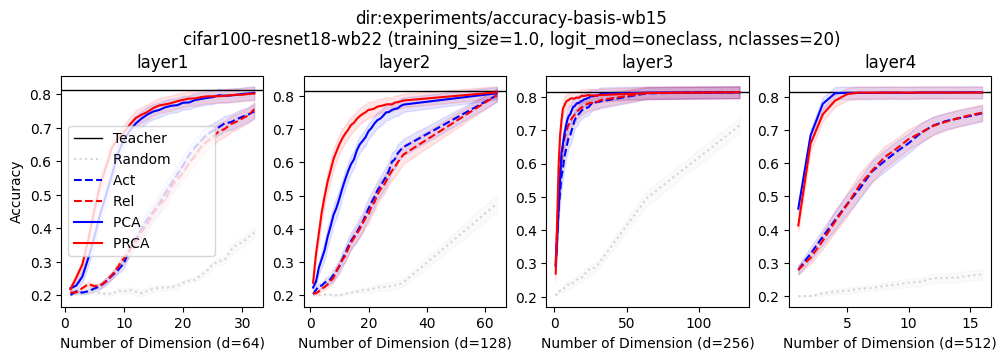

In [7]:
for model_name in [
    
    "cifar100-resnet18-wb15e151",# remark: this is the second best model of `wb15`. The best one is e197 (or just `wb15`)
    "cifar100-resnet18-wb11",  # trained with 100 epochs
    "cifar100-resnet18-wb22", # similar to `wb11` but with 200 epochs
    
]:
    
    accuracy_curve(
        arch=model_name,
        layers_and_factors = [
            ("layer1", 2),
            ("layer2", 2),
            ("layer3", 2),
            ("layer4", 32)
        ],
    )

## Analysis of `cifar100-resnet18-wb15e*`

### Quality of Basis Across Epochs

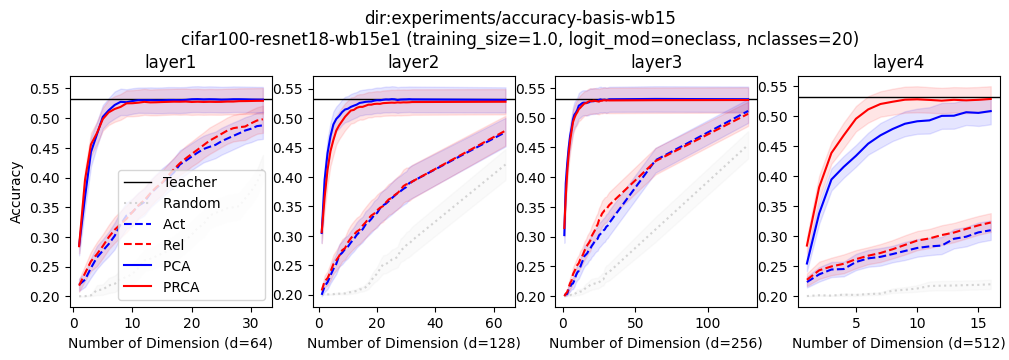

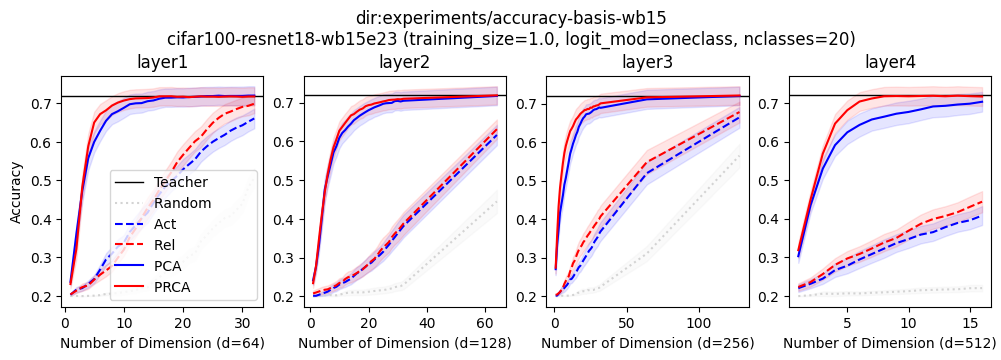

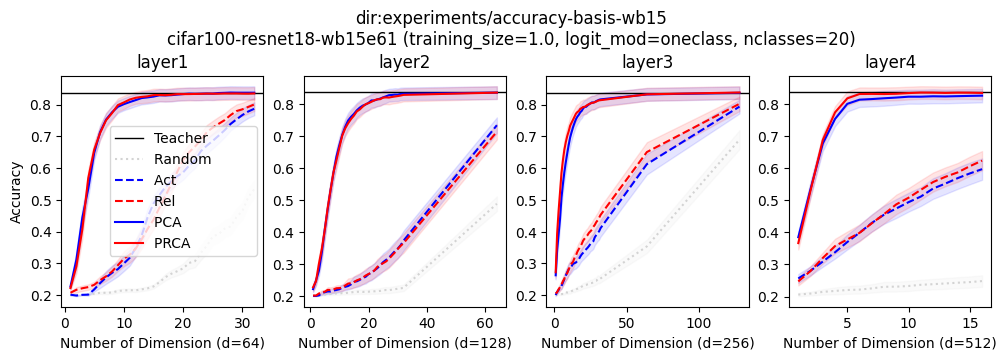

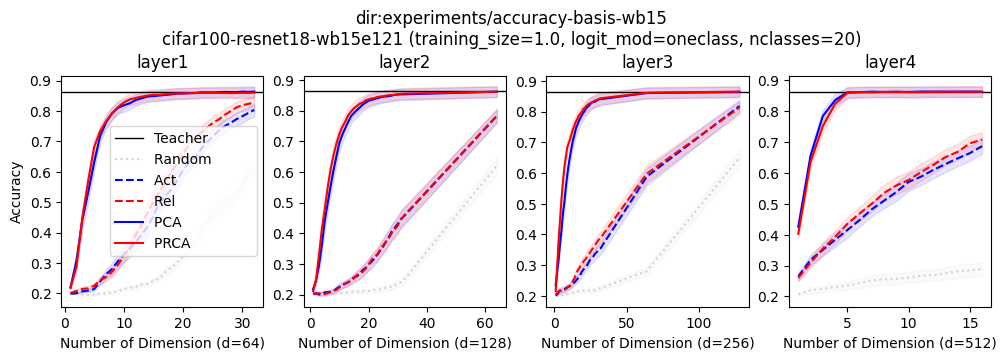

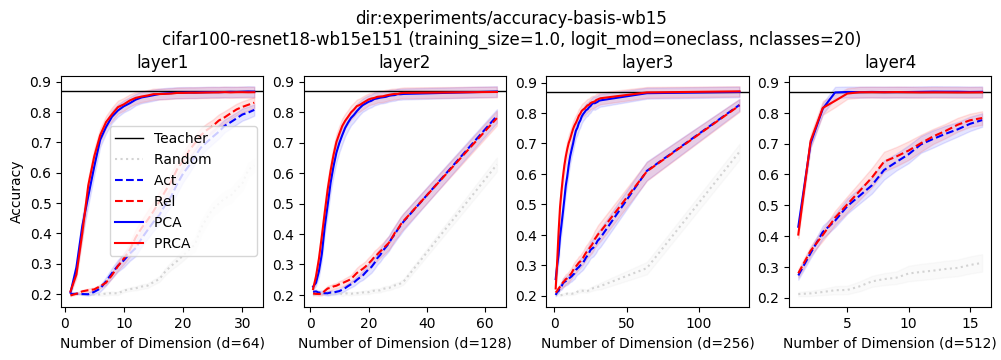

In [8]:
for epoch in [1, 23, 61, 121, 151]:
    accuracy_curve(
        arch=f"cifar100-resnet18-wb15e{epoch}",
        layers_and_factors = [
            ("layer1", 2),
            ("layer2", 2),
            ("layer3", 2),
            ("layer4", 32)
        ],
    )

### Quality of Basese when building with different training sizes

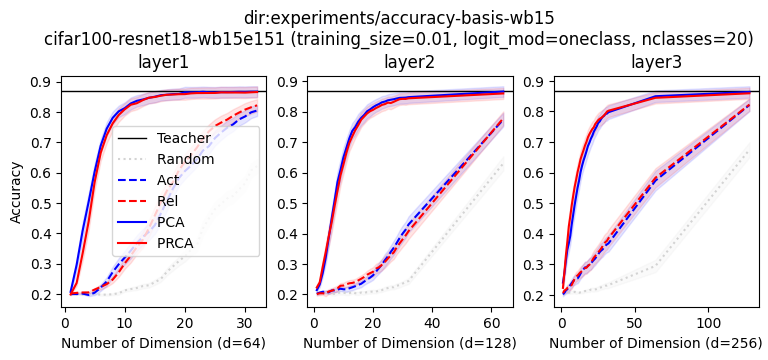

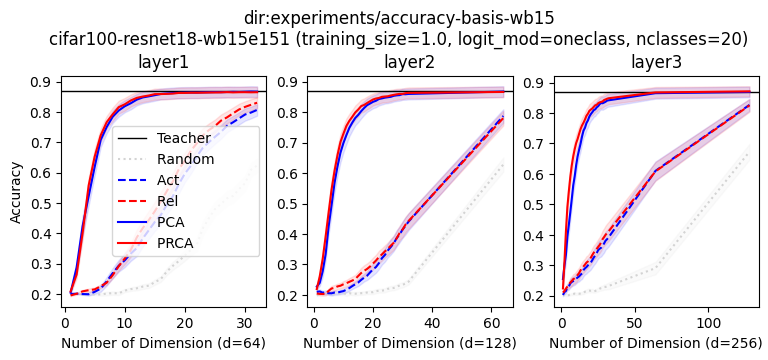

In [9]:
for training_size in [0.01, 1.0]:
    accuracy_curve(
        arch="cifar100-resnet18-wb15e151",
        layers_and_factors = [
            ("layer1", 2),
            ("layer2", 2),
            ("layer3", 2),
        ],
        training_size=training_size,
    )

### Comparison between logit modifiers

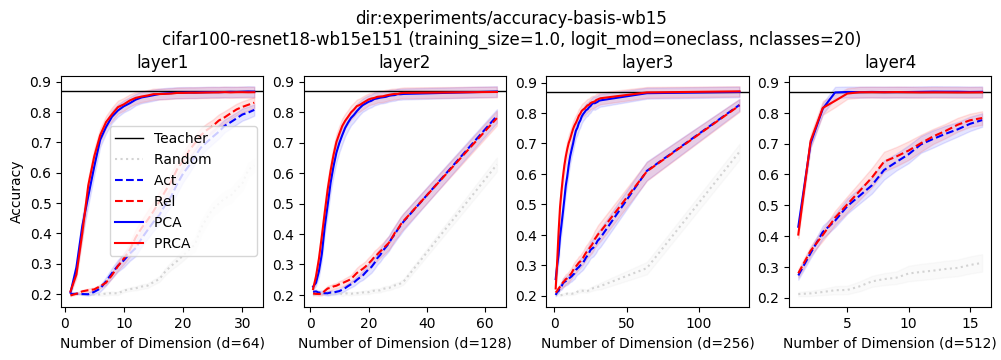

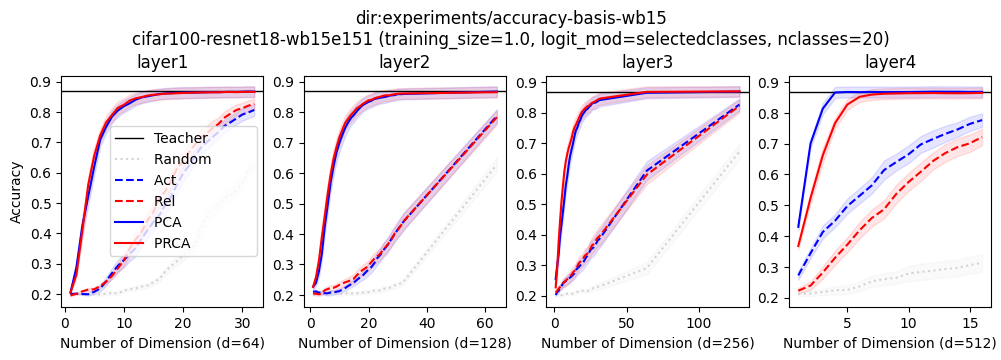

In [10]:
for logit_mod in ['oneclass', 'selectedclasses']:
    accuracy_curve(
        arch="cifar100-resnet18-wb15e151",
        layers_and_factors = [
            ("layer1", 2),
            ("layer2", 2),
            ("layer3", 2),
            ("layer4", 32)
        ],
        logit_mod=logit_mod,
    )

# Summary

**Aims**:
1. Efficacy of PRCA in different models (same architecture but trained with different configurations). Particularly,
    - [`cifar100-resnet18-wb11`][wb11] and [`cifar100-resnet18-wb22`][wb22]: these two models are trained with almost the same configuration, the number of epochs are `100` and `200` .
    - [`cifar100-resnet18-wb15e151`][wb15]: The model is trained with a configuration used in [a paper][1], and it can reach accuracy at `~0.77`, which is very high. Noting that this model is the 2nd best checkpoing of `cifar100-resnet18-wb15`.
    
2. Analysis of `cifar100-resnet18-wb15` at different epochs (checkpoints). 


**Conclusions**
1. For the `wb11` and `wb22` models, which has higher training loss than `wb15`, we could see that the difference between PRCA and PCA is *substantial*, except in `layer4`. we do NOT see such a different between the two bases in `wb15`.
2. For checkpoints of `wb15`, we could see that, already after the 1st epoch, PCA and PRCA do NOT have any difference, except `layer4`. In the caes of `layer4`, we could see that the difference between PCA and PRCA is large until `epoch=23`.

3. Follow-up analysis on `wb15`:
- the traning size does NOT seem to infleunce the trend between PCA and PRCA.
- (logit comparison): so far, `oneclass` logit modifier performs the best for PRCA.That is we compute the context vectors from the logit of the target class. 


[1]: https://arxiv.org/pdf/1708.04552.pdf

[wb11]: https://wandb.ai/p16i/xaikd-training-teacher-models/runs/f8ujj0yb
[wb22]: https://wandb.ai/p16i/xaikd-training-teacher-models/runs/vwjm7t8v?workspace=user-p16i
[wb15]: https://wandb.ai/p16i/xaikd-training-teacher-models/runs/lwnx8qeo?workspace=user-p16i